# Submission archive metric benchmark (subs 5–9, 22)

Compare **local** metrics on labeled **`train_soundscapes`** windows against your **Kaggle public LB** scores.

| Sub | Archive folder | Kaggle LB |
|-----|----------------|----------|
| 5 | `sub_5_29.04_v1.4` | 0.721 |
| 6 | `sub_6_29.04_v1.5` | 0.720 |
| 7 | `sub_7_30.04_v1.6_sec_label_1_0` | 0.720 |
| 8 | `sub_8_30.04_v1.7_sec_label_weighted_0_5` | 0.720 |
| 9 | `sub_9_30.04_v2.0_pretrained` | 0.620 |
| 22 | `sub_22_v3.2_Perch_Agent` | 0.880 |

**CNN (5–9):** load archived `model.keras`, predict on labeled `train_soundscapes` windows.  
**Sub 22 (Perch):** load archived `best_head.keras` + ONNX Perch, run the same soundscape windows (aligned by `row_id`), blend with `perch_weight` from `best_model_info.json`.

Metrics:
- **`evaluator_macro_auc`** — `src/evaluator.py` / competition macro ROC-AUC (classes with ≥1 positive in *that eval slice*)
- **`meta_agent_ge3`** — per-class AUC, species with ≥3 positives, both classes present (`meta_agent._macro_auc`)
- **`macro_auc_minpos_k`** — macro over species with ≥k positives
- **Subsampled rows** — e.g. only rows where top-50 species appear

Also shows **`archived_focal_auc`** from `final_eval_metrics.json` (focal `train_audio` — often ~0.98, **not** comparable to LB).

**Note:** If you previously ran this notebook and saw `evaluator_macro_auc = 1.0` for all CNN subs, delete `notebooks/cache/submission_preds/*.npz` and re-run inference — an old `align_predictions` bug compared labels to themselves.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

# Avoid Jupyter hanging on Keras/tqdm progress bars when ipywidgets is missing.
os.environ.setdefault("TQDM_DISABLE", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy.stats import spearmanr, pearsonr

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from submission_benchmark import (
    build_soundscape_ground_truth,
    predict_cnn_on_labeled_rows,
    predict_perch_on_labeled_rows,
    align_predictions,
    compute_all_metrics,
    subsample_masks,
    load_archived_focal_auc,
)

DATA_DIR = ROOT / "data"
ARCHIVE = ROOT / "submission_archive"
CACHE = ROOT / "notebooks" / "cache" / "submission_preds"
CACHE.mkdir(parents=True, exist_ok=True)

KAGGLE_LB = {5: 0.721, 6: 0.720, 7: 0.720, 8: 0.720, 9: 0.620, 22: 0.880}

SUBMISSIONS = {
    5: ARCHIVE / "sub_5_29.04_v1.4",
    6: ARCHIVE / "sub_6_29.04_v1.5",
    7: ARCHIVE / "sub_7_30.04_v1.6_sec_label_1_0",
    8: ARCHIVE / "sub_8_30.04_v1.7_sec_label_weighted_0_5",
    9: ARCHIVE / "sub_9_30.04_v2.0_pretrained",
    22: ARCHIVE / "sub_22_v3.2_Perch_Agent",
}

print("ROOT:", ROOT)
print("TensorFlow:", tf.__version__)

ROOT: /Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT
TensorFlow: 2.21.0


In [2]:
y_true_df, ogg_paths = build_soundscape_ground_truth(
    DATA_DIR / "train_soundscapes_labels.csv",
    DATA_DIR / "sample_submission.csv",
    DATA_DIR / "train_soundscapes",
)
species_cols = list(y_true_df.columns)
print("Labeled windows:", len(y_true_df))
print("Species with >=1 positive:", int((y_true_df.sum(axis=0) > 0).sum()))

Labeled windows: 739
Species with >=1 positive: 75


In [3]:
RUN_INFERENCE = True  # False = reuse cached .npz in notebooks/cache/submission_preds/

# Pick up edits to src/submission_benchmark.py without restarting the kernel.
import importlib
import submission_benchmark as _sb
importlib.reload(_sb)
from submission_benchmark import (
    predict_cnn_on_labeled_rows,
    predict_perch_on_labeled_rows,
)  # noqa: F401

rng = np.random.default_rng(42)
rows_out = []

for sub_id, folder in SUBMISSIONS.items():
    folder = Path(folder)
    print(f"\n=== Sub {sub_id}: {folder.name} ===")

    record = {
        "sub_id": sub_id,
        "folder": folder.name,
        "kaggle_lb": KAGGLE_LB.get(sub_id),
        "archived_focal_auc": load_archived_focal_auc(folder),
    }

    cache_npz = CACHE / f"sub_{sub_id}_preds.npz"

    if sub_id == 22:
        head_path = folder / "best_head.keras"
        if not head_path.exists():
            head_path = folder / "final_head.keras"
        if not head_path.exists():
            print("  SKIP: no Perch head (.keras)")
            continue
        record["source"] = "perch_soundscapes"
        if cache_npz.exists() and not RUN_INFERENCE:
            d = np.load(cache_npz)
            yt, yscore = d["y_true"], d["y_pred"]
        else:
            print("  Running Perch ONNX + head on soundscapes …")
            pred_df = predict_perch_on_labeled_rows(
                folder, y_true_df, DATA_DIR / "train_soundscapes"
            )
            yt, yscore, _ = align_predictions(y_true_df, pred_df)
            np.savez_compressed(cache_npz, y_true=yt, y_pred=yscore)
        record["n_aligned"] = len(yt)
        print(f"  Aligned windows: {len(yt)}")
    else:
        model_path = folder / "model.keras"
        if not model_path.exists():
            print("  SKIP: no model.keras")
            continue
        record["source"] = "cnn_keras"
        if cache_npz.exists() and not RUN_INFERENCE:
            d = np.load(cache_npz)
            yt, yscore = d["y_true"], d["y_pred"]
        else:
            print("  Loading model.keras (can take 1–3 min on first TF use) …")
            model = tf.keras.models.load_model(str(model_path))
            print("  Running soundscape inference …")
            pred_df = predict_cnn_on_labeled_rows(
                model, y_true_df, DATA_DIR / "train_soundscapes"
            )
            yt, yscore, _ = align_predictions(y_true_df, pred_df)
            np.savez_compressed(cache_npz, y_true=yt, y_pred=yscore)
            del model
            tf.keras.backend.clear_session()
        record["n_aligned"] = len(yt)
        print(f"  Aligned windows: {len(yt)}")

    record.update(compute_all_metrics(yt, yscore))
    for mname, mask in subsample_masks(yt, rng).items():
        if mask.sum() == 0:
            continue
        m = compute_all_metrics(yt, yscore, mask=mask)
        record[f"evaluator_auc__{mname}"] = m.get("evaluator_macro_auc", float("nan"))
        record[f"meta_ge3__{mname}"] = m.get("meta_agent_ge3", float("nan"))
        record[f"n__{mname}"] = m.get("n_samples", 0)
    rows_out.append(record)

results = pd.DataFrame(rows_out).sort_values("sub_id")
results


=== Sub 5: sub_5_29.04_v1.4 ===
  Loading model.keras (can take 1–3 min on first TF use) …
  Running soundscape inference …
  Warming up TensorFlow graph (first predict can take 1–3 min in notebooks) …
  Warmup done.
  CNN inference: 66 labeled soundscape file(s), 739 row_id(s)
  … file 1/66: BC2026_Train_0001_S08_20250606_030007


/Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 64, 128, 1))
  warnings.warn(msg)


    predict 12 window(s) …
    first file done.


/Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(12, 64, 128, 1))
  warnings.warn(msg)
/Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(2, 64, 128, 1))
  warnings.warn(msg)
/Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(8, 64, 128, 1))
  warnings.warn(msg)
/Users/enricozafiris/

  … file 10/66: BC2026_Train_0010_S09_20250828_000000


...

/Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(5, 64, 128, 1))
  warnings.warn(msg)
/Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(3, 64, 128, 1))
  warnings.warn(msg)


  … file 20/66: BC2026_Train_0020_S22_20211104_231500


/Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(9, 64, 128, 1))
  warnings.warn(msg)


  … file 30/66: BC2026_Train_0030_S22_20211212_224500
  … file 40/66: BC2026_Train_0040_S22_20220101_014500
  … file 50/66: BC2026_Train_0050_S22_20220205_214500
  CNN inference: 50/66 soundscape files
  … file 60/66: BC2026_Train_0060_S15_20250617_062700
  … file 66/66: BC2026_Train_0066_S23_20241124_044002
  Aligned windows: 739

=== Sub 22: sub_22_v3.2_Perch_Agent ===


,sub_id,folder,kaggle_lb,archived_focal_auc,source,n_aligned,n_samples,evaluator_macro_auc,evaluator_n_scored_species,macro_auc_minpos_1,...,n__rows_top10_species,evaluator_auc__rows_top25_species,meta_ge3__rows_top25_species,n__rows_top25_species,evaluator_auc__rows_top50_species,meta_ge3__rows_top50_species,n__rows_top50_species,evaluator_auc__rows_ge3_species_present,meta_ge3__rows_ge3_species_present,n__rows_ge3_species_present
0,5,sub_5_29.04_v1.4,0.721,0.985879,cnn_keras,739,739.0,0.688521,75.0,0.688521,...,627.0,0.682230,0.693037,712.0,0.681621,0.690910,735.0,0.681621,0.690910,735.0
1,6,sub_6_29.04_v1.5,0.720,0.996108,cnn_keras,739,739.0,0.723978,75.0,0.723978,...,627.0,0.718778,0.719043,712.0,0.717453,0.714780,735.0,0.717453,0.714780,735.0
2,7,sub_7_30.04_v1.6_sec_label_1_0,0.720,0.996108,cnn_keras,739,739.0,0.723978,75.0,0.723978,...,627.0,0.718778,0.719043,712.0,0.717453,0.714780,735.0,0.717453,0.714780,735.0
3,8,sub_8_30.04_v1.7_sec_label_weighted_0_5,0.720,0.996108,cnn_keras,739,739.0,0.723978,75.0,0.723978,...,627.0,0.718778,0.719043,712.0,0.717453,0.714780,735.0,0.717453,0.714780,735.0
4,9,sub_9_30.04_v2.0_pretrained,0.620,NaN,cnn_keras,739,739.0,0.527814,75.0,0.527814,...,627.0,0.518480,0.541086,712.0,0.521335,0.541642,735.0,0.521335,0.541642,735.0
5,22,sub_22_v3.2_Perch_Agent,0.880,NaN,perch_cached_val,739,739.0,0.684730,75.0,0.684730,...,627.0,0.674621,0.648380,712.0,0.675490,0.644518,735.0,0.675490,0.644518,735.0


In [4]:
core = ["sub_id", "folder", "kaggle_lb", "archived_focal_auc", "n_aligned",
        "evaluator_macro_auc", "meta_agent_ge3", "macro_auc_minpos_1",
        "macro_auc_minpos_3", "macro_auc_minpos_5", "macro_map_minpos_1"]
results[[c for c in core if c in results.columns]]

,sub_id,folder,kaggle_lb,archived_focal_auc,n_aligned,evaluator_macro_auc,meta_agent_ge3,macro_auc_minpos_1,macro_auc_minpos_3,macro_auc_minpos_5,macro_map_minpos_1
0,5,sub_5_29.04_v1.4,0.721,0.985879,739,0.688521,0.690177,0.688521,0.690177,0.686270,0.206979
1,6,sub_6_29.04_v1.5,0.720,0.996108,739,0.723978,0.713832,0.723978,0.713832,0.703085,0.206992
2,7,sub_7_30.04_v1.6_sec_label_1_0,0.720,0.996108,739,0.723978,0.713832,0.723978,0.713832,0.703085,0.206992
3,8,sub_8_30.04_v1.7_sec_label_weighted_0_5,0.720,0.996108,739,0.723978,0.713832,0.723978,0.713832,0.703085,0.206992
4,9,sub_9_30.04_v2.0_pretrained,0.620,NaN,739,0.527814,0.542561,0.527814,0.542561,0.545372,0.108066
5,22,sub_22_v3.2_Perch_Agent,0.880,NaN,739,0.684730,0.645338,0.684730,0.645338,0.631335,0.292412


In [5]:
metric_cols = [c for c in results.columns
               if c.startswith(("evaluator_macro", "meta_agent", "macro_auc", "macro_map"))
               and "__" not in c]
lb = results["kaggle_lb"].astype(float).values
corr_rows = []
for col in metric_cols:
    x = results[col].astype(float).values
    m = np.isfinite(x) & np.isfinite(lb)
    if m.sum() < 3:
        continue
    sp, _ = spearmanr(lb[m], x[m])
    pe, _ = pearsonr(lb[m], x[m])
    corr_rows.append({"metric": col, "spearman_vs_lb": sp, "pearson_vs_lb": pe})
pd.DataFrame(corr_rows).sort_values("spearman_vs_lb", ascending=False)

/var/folders/mr/1l42j85s2lx8dfsbtglzjqwc0000gn/T/ipykernel_79942/2711190848.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp, _ = spearmanr(lb[m], x[m])
/var/folders/mr/1l42j85s2lx8dfsbtglzjqwc0000gn/T/ipykernel_79942/2711190848.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pe, _ = pearsonr(lb[m], x[m])


,metric,spearman_vs_lb,pearson_vs_lb
8,macro_map_minpos_1,0.612903,0.970261
0,evaluator_macro_auc,-0.032258,0.503647
1,macro_auc_minpos_1,-0.032258,0.503647
2,macro_auc_minpos_2,-0.032258,0.458858
3,macro_auc_minpos_3,-0.032258,0.310903
4,macro_auc_minpos_5,-0.032258,0.255019
5,macro_auc_minpos_10,-0.032258,0.194836
6,meta_agent_ge3,-0.032258,0.310903
7,meta_agent_ge3_n_species,NaN,NaN


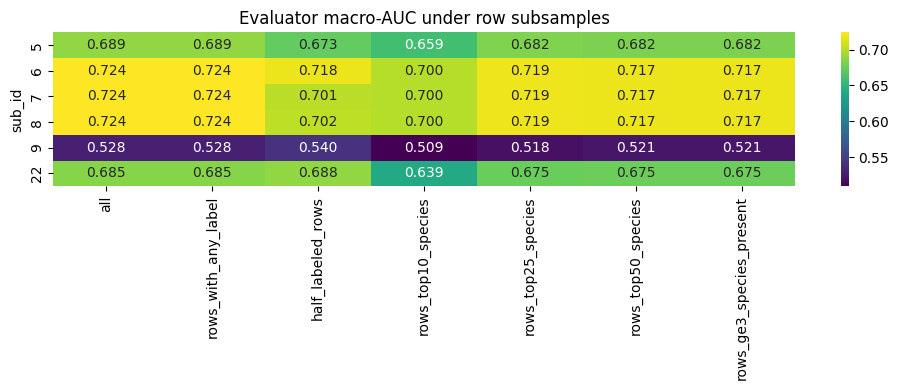

In [6]:
sub_cols = [c for c in results.columns if c.startswith("evaluator_auc__")]
if sub_cols:
    hm = results.set_index("sub_id")[sub_cols].astype(float)
    hm.columns = [c.replace("evaluator_auc__", "") for c in hm.columns]
    plt.figure(figsize=(10, 4))
    sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Evaluator macro-AUC under row subsamples")
    plt.tight_layout()
    plt.show()

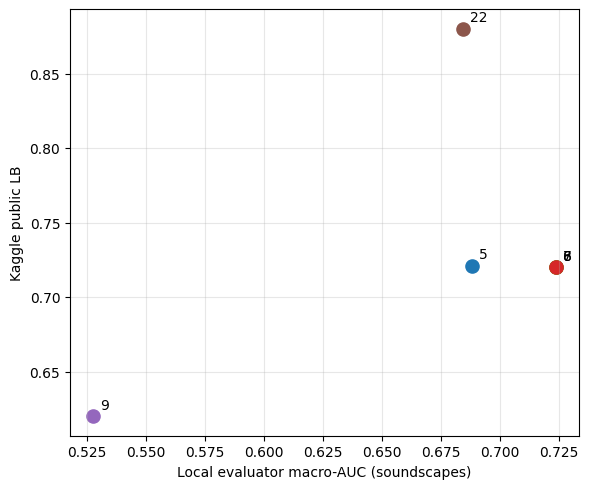

In [7]:
xcol, ycol = "evaluator_macro_auc", "kaggle_lb"
fig, ax = plt.subplots(figsize=(6, 5))
for _, r in results.iterrows():
    ax.scatter(r[xcol], r[ycol], s=90)
    ax.annotate(str(int(r["sub_id"])), (r[xcol], r[ycol]),
                textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Local evaluator macro-AUC (soundscapes)")
ax.set_ylabel("Kaggle public LB")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
out = ROOT / "notebooks" / "cache" / "submission_metric_benchmark.csv"
results.to_csv(out, index=False)
print("Saved", out)

Saved /Users/enricozafiris/Desktop/Catolica/T4 Advanced Predictive Analytics/MERGED AGENT/notebooks/cache/submission_metric_benchmark.csv
